Columns in dataset:
['sched_dep_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight', 'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute', 'time_hour']

Shape after cleaning: (422818, 16)

Delay counts:
Delay
0    335322
1     87496
Name: count, dtype: int64

Delay proportions:
Delay
0    0.793
1    0.207
Name: proportion, dtype: float64


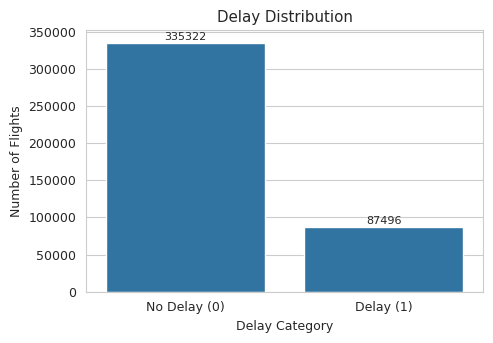

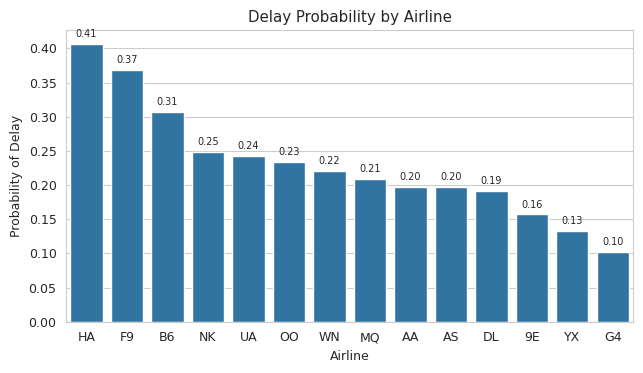

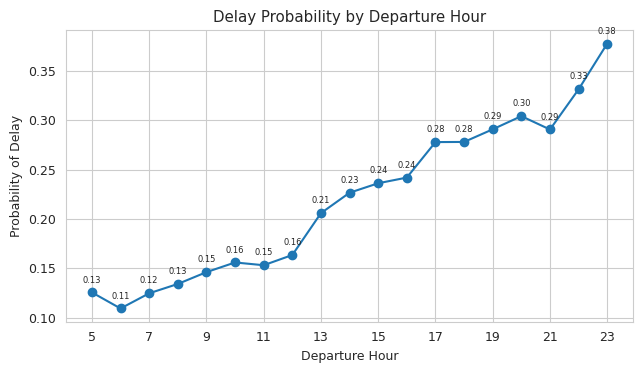

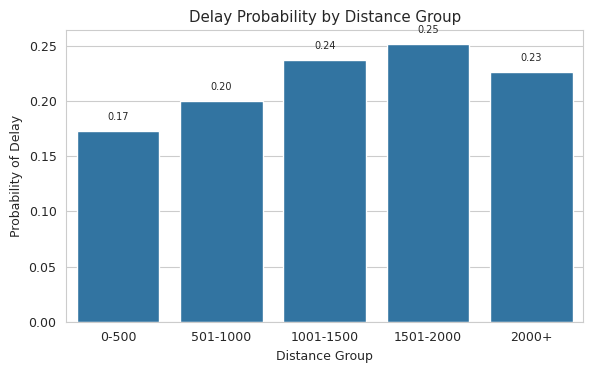

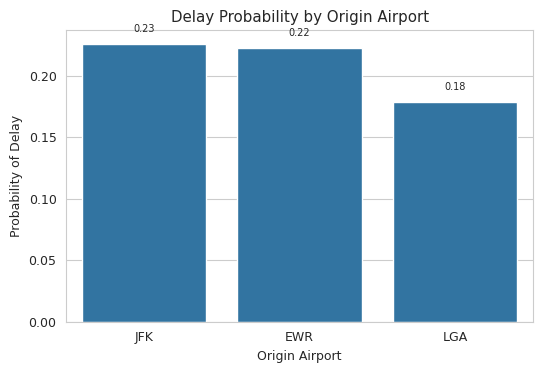

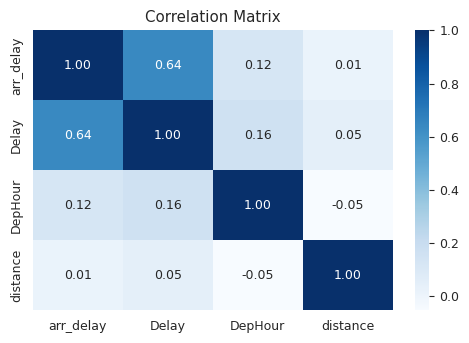


Delay probability by airline:
carrier
HA    0.406
F9    0.369
B6    0.307
NK    0.249
UA    0.243
OO    0.234
WN    0.221
MQ    0.209
AA    0.198
AS    0.197
DL    0.192
9E    0.157
YX    0.132
G4    0.102
Name: Delay, dtype: float64

Delay probability by departure hour:
DepHour
5     0.126
6     0.109
7     0.125
8     0.134
9     0.146
10    0.156
11    0.153
12    0.164
13    0.206
14    0.227
15    0.236
16    0.242
17    0.278
18    0.278
19    0.291
20    0.304
21    0.290
22    0.331
23    0.377
Name: Delay, dtype: float64

Delay probability by distance group:
DistanceGroup
0-500        0.173
501-1000     0.200
1001-1500    0.237
1501-2000    0.251
2000+        0.226
Name: Delay, dtype: float64

Delay probability by origin airport:
origin
JFK    0.226
EWR    0.222
LGA    0.179
Name: Delay, dtype: float64

Variation in delay probability:
Airline range: 0.304
Departure hour range: 0.268
Distance group range: 0.079
Origin airport range: 0.047


In [1]:
# =========================================================
# EDA: Flight Delay Prediction Using Historical Airline Data
# =========================================================

# -----------------------------
# 1. Import libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (6, 3.8)
plt.rcParams["font.size"] = 9

# -----------------------------
# 2. Load dataset
# -----------------------------
df = pd.read_csv("Flights1.csv")

# -----------------------------
# 3. Check available columns
# -----------------------------
print("Columns in dataset:")
print(df.columns.tolist())

# -----------------------------
# 4. Data cleaning and target creation
# -----------------------------
# Remove rows with missing arrival delay
df = df.dropna(subset=['arr_delay']).copy()

# Binary target:
# 0 = No Delay, 1 = Delay
df['Delay'] = np.where(df['arr_delay'] > 15, 1, 0)

# Extract departure hour
df['DepHour'] = df['sched_dep_time'] // 100

# Create distance groups for clearer plots
df['DistanceGroup'] = pd.cut(
    df['distance'],
    bins=[0, 500, 1000, 1500, 2000, df['distance'].max()],
    labels=['0-500', '501-1000', '1001-1500', '1501-2000', '2000+'],
    include_lowest=True
)

# -----------------------------
# 5. Dataset summary
# -----------------------------
print("\nShape after cleaning:", df.shape)
print("\nDelay counts:")
print(df['Delay'].value_counts().sort_index())
print("\nDelay proportions:")
print(df['Delay'].value_counts(normalize=True).sort_index().round(3))

# -----------------------------
# 6. Plot 1: Delay distribution
# Supports RQ1
# -----------------------------
delay_counts = df['Delay'].value_counts().sort_index()

plt.figure(figsize=(5, 3.5))
ax = sns.barplot(x=['No Delay (0)', 'Delay (1)'], y=delay_counts.values)
plt.title("Delay Distribution")
plt.xlabel("Delay Category")
plt.ylabel("Number of Flights")

for i, v in enumerate(delay_counts.values):
    ax.text(i, v + max(delay_counts.values)*0.01, f"{v}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# -----------------------------
# 7. Plot 2: Delay probability by airline
# Supports RQ2 and RQ3
# -----------------------------
airline_delay = df.groupby('carrier')['Delay'].mean().sort_values(ascending=False)

plt.figure(figsize=(6.5, 3.8))
ax = sns.barplot(x=airline_delay.index, y=airline_delay.values)
plt.title("Delay Probability by Airline")
plt.xlabel("Airline")
plt.ylabel("Probability of Delay")

for i, v in enumerate(airline_delay.values):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=7)

plt.tight_layout()
plt.show()

# -----------------------------
# 8. Plot 3: Delay probability by departure hour
# Supports RQ2
# -----------------------------
hour_delay = df.groupby('DepHour')['Delay'].mean()

plt.figure(figsize=(6.5, 3.8))
plt.plot(hour_delay.index, hour_delay.values, marker='o')
plt.title("Delay Probability by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Probability of Delay")
plt.xticks(range(int(df['DepHour'].min()), int(df['DepHour'].max()) + 1, 2))

for x, y in zip(hour_delay.index, hour_delay.values):
    plt.text(x, y + 0.01, f"{y:.2f}", ha='center', fontsize=6)

plt.tight_layout()
plt.show()

# -----------------------------
# 9. Plot 4: Delay probability by distance group
# Supports RQ2
# -----------------------------
distance_delay = df.groupby('DistanceGroup', observed=False)['Delay'].mean()

plt.figure(figsize=(6, 3.8))
ax = sns.barplot(x=distance_delay.index, y=distance_delay.values)
plt.title("Delay Probability by Distance Group")
plt.xlabel("Distance Group")
plt.ylabel("Probability of Delay")

for i, v in enumerate(distance_delay.values):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=7)

plt.tight_layout()
plt.show()

# -----------------------------
# 10. Plot 5: Delay probability by origin airport
# Supports RQ3
# -----------------------------
if 'origin' in df.columns:
    airport_delay = df.groupby('origin')['Delay'].mean().sort_values(ascending=False)

    plt.figure(figsize=(5.5, 3.8))
    ax = sns.barplot(x=airport_delay.index, y=airport_delay.values)
    plt.title("Delay Probability by Origin Airport")
    plt.xlabel("Origin Airport")
    plt.ylabel("Probability of Delay")

    for i, v in enumerate(airport_delay.values):
        ax.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=7)

    plt.tight_layout()
    plt.show()

# -----------------------------
# 11. Correlation heatmap
# Supports RQ1 and RQ2
# -----------------------------
corr_cols = ['arr_delay', 'Delay', 'DepHour', 'distance']
corr_data = df[corr_cols].corr()

plt.figure(figsize=(5, 3.5))
sns.heatmap(corr_data, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# -----------------------------
# 12. Summary tables
# -----------------------------
print("\nDelay probability by airline:")
print(airline_delay.round(3))

print("\nDelay probability by departure hour:")
print(hour_delay.round(3))

print("\nDelay probability by distance group:")
print(distance_delay.round(3))

if 'origin' in df.columns:
    print("\nDelay probability by origin airport:")
    print(airport_delay.round(3))

# -----------------------------
# 13. Simple variability check
# Higher range = stronger variation in delay probability
# -----------------------------
print("\nVariation in delay probability:")
print("Airline range:", round(airline_delay.max() - airline_delay.min(), 3))
print("Departure hour range:", round(hour_delay.max() - hour_delay.min(), 3))
print("Distance group range:", round(distance_delay.max() - distance_delay.min(), 3))

if 'origin' in df.columns:
    print("Origin airport range:", round(airport_delay.max() - airport_delay.min(), 3))